**🧮 Customer Lifetime Value (LTV) Prediction**

This notebook builds a predictive model for estimating Customer Lifetime Value using the Online Retail dataset.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datetime import timedelta
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

**📥 Step 1: Load and Preview the Data**

In [5]:
# Load Excel data
file_path = '/content/Online Retail.xlsx'
df = pd.read_excel(file_path)

In [6]:
# Preview data
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

**📋 Step 2: Clean and Preprocess**

Key cleaning steps:
* Remove missing CustomerID
* Remove cancelled orders (InvoiceNo starting with 'C')
* Filter for positive quantities and prices
* Convert date to datetime format

In [8]:
# Clean data
# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
# Filter for valid quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create a TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


**Feature Engineering for LTV Prediction**

We'll compute:

Recency: Days since last purchase

Frequency: Number of purchases

Monetary: Total amount spent

AOV: Average order value

Tenure: Days between first and last purchase

In [9]:
from datetime import timedelta

snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': [lambda x: (snapshot_date - x.max()).days, lambda x: (x.max() - x.min()).days],
    'InvoiceNo': 'nunique',
    'TotalAmount': ['sum', 'mean']
})

customer_df.columns = ['recency', 'tenure', 'frequency', 'monetary', 'aov']
customer_df = customer_df.reset_index()
customer_df.head()

,CustomerID,recency,tenure,frequency,monetary,aov
0,12346.0,326,0,1,77183.60,77183.600000
1,12347.0,2,365,7,4310.00,23.681319
2,12348.0,75,282,4,1797.24,57.975484
3,12349.0,19,0,1,1757.55,24.076027
4,12350.0,310,0,1,334.40,19.670588


**Train/Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X = customer_df.drop(['CustomerID', 'monetary'], axis=1)
y = customer_df['monetary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Model Training (XGBoost)**

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


MAE: 1870.47, RMSE: 14116.34


**Predict and Segment Customers by LTV**

In [13]:
customer_df['predicted_ltv'] = model.predict(customer_df.drop(['CustomerID', 'monetary'], axis=1))
customer_df['segment'] = pd.qcut(customer_df['predicted_ltv'], q=3, labels=['Low', 'Medium', 'High'])
customer_df[['CustomerID', 'predicted_ltv', 'segment']].head()


,CustomerID,predicted_ltv,segment
0,12346.0,60561.265625,High
1,12347.0,3020.940674,High
2,12348.0,1886.028809,High
3,12349.0,514.785706,Low
4,12350.0,402.554382,Low


**Feature Importance (XGBoost)**

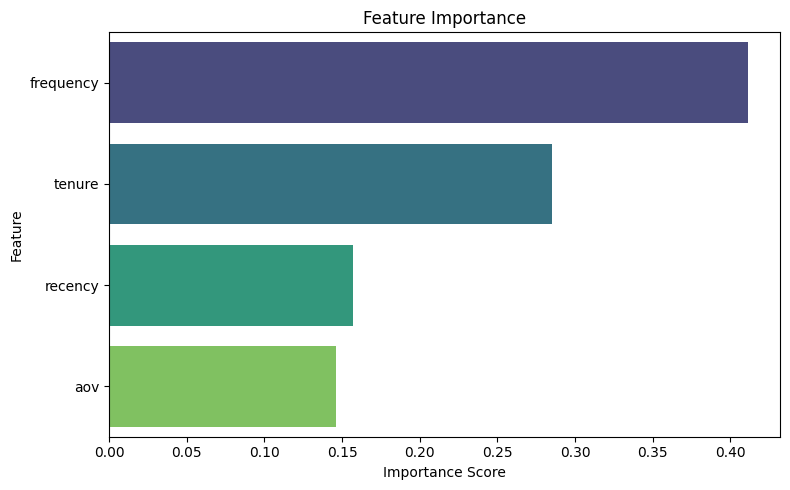

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', hue = 'feature' , palette='viridis' , legend=False)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Distribution of Predicted LTV**

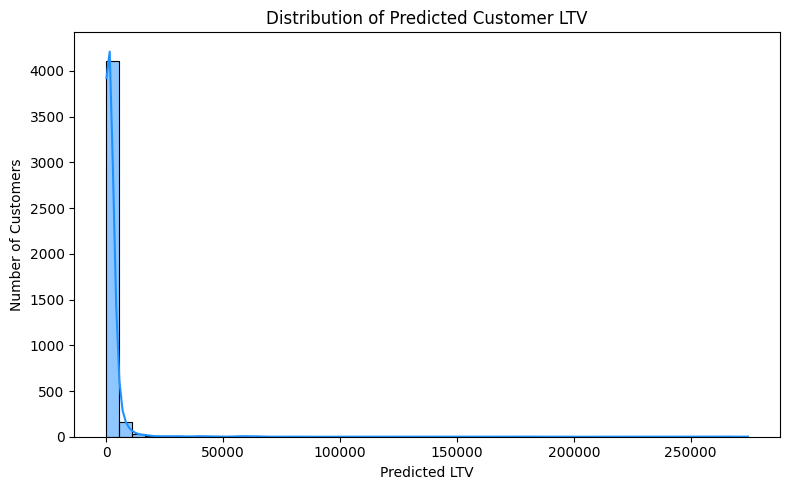

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(customer_df['predicted_ltv'], bins=50, kde=True, color='dodgerblue')
plt.title('Distribution of Predicted Customer LTV')
plt.xlabel('Predicted LTV')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

** LTV by Customer Segment**

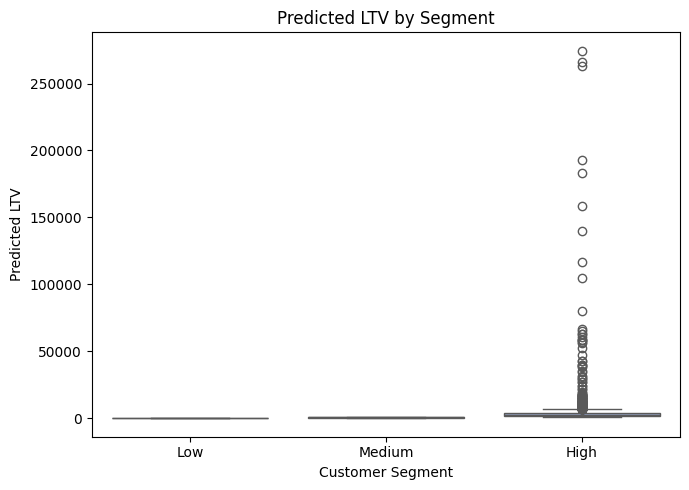

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=customer_df, x='segment', y='predicted_ltv', hue ='segment', palette='Set2', legend=False)
plt.title('Predicted LTV by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Predicted LTV')
plt.tight_layout()
plt.show()

In [20]:
import joblib

joblib.dump(model, 'ltv_model.pkl')
customer_df.to_csv('ltv_predictions.csv', index=False)